In [ ]:
import sys
MODULEPATH="../../"
sys.path.append(MODULEPATH)
sys.path.append('../')
from connectivity.plot_results import plot_results_with_paths, plot_saddle_tree_with_function

from critical_points.torch_critical_point_finder import find_critical_points_torch, save_critical_points_to_csv
from test_schwefel.schwefel_function_nnmodule import Schwefel2D, schwefel_loss, schwefel2D_numpy 

import matplotlib.pyplot as plt
import pandas as pd


In [2]:
model_builder = lambda p: Schwefel2D(*p)

In [3]:
# Set parameters
BOUNDS = (0.0, 1.0)
DIM = 2
ATTEMPTS = 32
MIN_DISTANCE = 0.01


In [4]:
# Run search
minima, maxima, saddles = find_critical_points_torch(
    model_builder=model_builder,
    loss_func=schwefel_loss,
    input = [],             # placeholder model input for compatibility (Schwefel model has no model input)
    bounds=BOUNDS,
    dimension=DIM,
    num_attempts=ATTEMPTS,
    min_distance=MIN_DISTANCE,
    device="cpu",
    lr=1e-1,
    steps=1_000,
    seed=1101
)



Attempt 1/32: starting point [0.25317813 0.88321528]


/usr/local/lib/python3.10/dist-packages/torch/autograd/graph.py:829: UserWarning: Using backward() with create_graph=True will create a reference cycle between the parameter and its gradient which can cause a memory leak. We recommend using autograd.grad when creating the graph to avoid this. If you have to use this function, make sure to reset the .grad fields of your parameters to None after use to break the cycle and avoid the leak. (Triggered internally at /pytorch/torch/csrc/autograd/engine.cpp:1291.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Converged after 125 iterations.
grad tensor([7.4360e-06, 5.3740e-06], grad_fn=<CatBackward0>)
[1.13144125 0.8243751 ] Reject: False
saddle tensor([1.1314, 0.8244])

Attempt 2/32: starting point [0.76250551 0.35659261]
Converged after 120 iterations.
grad tensor([-9.0942e-06,  2.4583e-06], grad_fn=<CatBackward0>)
[0.82437481 0.3418095 ] Reject: False
minimum tensor([0.8244, 0.3418])

Attempt 3/32: starting point [0.65636731 0.73049768]
Converged after 125 iterations.
grad tensor([-7.0573e-06, -6.9680e-06], grad_fn=<CatBackward0>)
[0.56116666 0.82437486] Reject: False
saddle tensor([0.5612, 0.8244])

Attempt 4/32: starting point [0.17145488 0.00906608]
Converged after 111 iterations.
grad tensor([-2.2552e-06, -9.6532e-06], grad_fn=<CatBackward0>)
[0.1662875  0.03455063] Reject: False
saddle tensor([0.1663, 0.0346])

Attempt 5/32: starting point [0.07226059 0.52750919]
Converged after 118 iterations.
grad tensor([6.8745e-06, 6.5283e-06], grad_fn=<CatBackward0>)
[0.03455094 0.5611664 ] Rej

In [5]:
# Save to CSV
results_df = save_critical_points_to_csv(minima, saddles, dimension=DIM, filename="critical_points_schwefel_torch.csv")
display(results_df)

Saved critical_points_schwefel_torch.csv


,x1,x2,f_value,type,index
0,0.824375,0.341809,2.171397e-01,minimum,0
1,1.482369,0.824375,-2.960914e-01,minimum,0
2,0.824375,0.034551,3.553479e-01,minimum,0
3,0.034551,0.341809,5.724876e-01,minimum,0
4,0.824375,0.824375,2.545597e-08,minimum,0
5,0.341810,0.824375,2.171397e-01,minimum,0
6,0.341809,0.341809,4.342794e-01,minimum,0
7,1.131441,0.824375,9.761422e-01,saddle,1
8,0.561167,0.824375,7.195275e-01,saddle,1
9,0.166288,0.034551,8.972070e-01,saddle,1


/tmp/ipykernel_251082/4078144568.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig2.show()


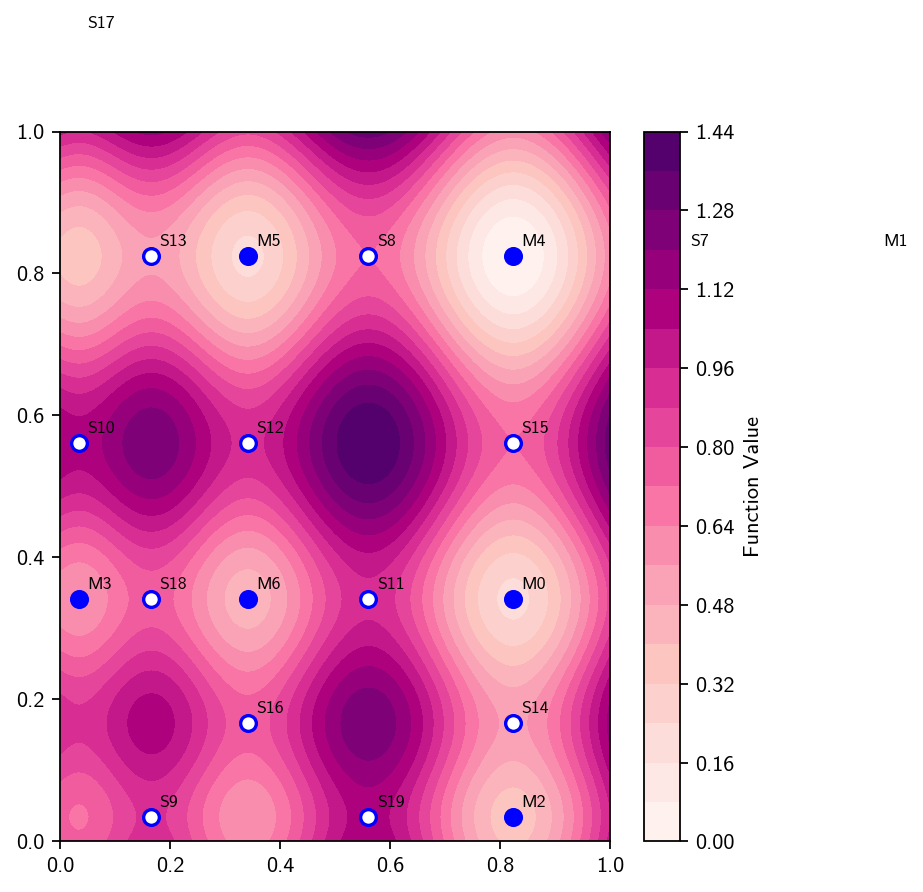

In [6]:
fig2 = plt.figure(figsize=(5,5), dpi=160)
fig2 = plot_results_with_paths(func=schwefel2D_numpy,  
                                critical_points_csv="critical_points_schwefel_torch.csv",
                                saddle_to_minima_csv=None, 
                                bounds=(0, 1),
                                res=200,
                                fig=fig2
)
plt.xlim(BOUNDS[0],BOUNDS[1])
plt.ylim(BOUNDS[0],BOUNDS[1])
fig2.show()
fig2.savefig("plots/landscape_paths.png")  # Optional